In [5]:
"""
Main experiment script for Random Geometric Graphs.
Sweeps m = 2, ..., 14 with 50 trials each.
Saves results and plots matched fraction vs m.
"""

import numpy as np
from tqdm import tqdm
from itertools import combinations
import os
import pickle
import matplotlib.pyplot as plt

# ============================================================
# Core functions
# ============================================================

def k_core(G, k=13):
    n = G.shape[0]
    dv = G.sum(axis=0).astype(int)
    active = np.ones(n, dtype=bool)
    changed = True
    while changed:
        changed = False
        to_remove = active & (dv < k)
        if not np.any(to_remove):
            break
        dv -= G[to_remove, :].sum(axis=0).astype(int)
        active[to_remove] = False
        changed = True
    return np.where(active & (dv >= k))[0]


def subsample(A, s):
    if s < 0 or s > 1:
        raise ValueError('Input value s must be between 0 and 1.')
    rows, cols = np.where(np.tril(A, k=-1) > 0)
    keep = np.random.rand(len(rows)) < s
    rows, cols = rows[keep], cols[keep]
    B = np.zeros_like(A)
    B[rows, cols] = 1
    B[cols, rows] = 1
    return B


def generate_rgg(n=10000, r=0.2, p=0.15):
    positions = np.random.rand(n, 2)
    diff = positions[:, None, :] - positions[None, :, :]
    dist_sq = np.sum(diff ** 2, axis=2)
    within_range = np.tril(dist_sq < r ** 2, k=-1)
    mask = within_range & (np.tril(np.random.rand(n, n), k=-1) < p)
    A = (mask + mask.T).astype(int)
    return A, positions


def intersect_and_kcore(A, B, k=13):
    intersection = A * B
    return k_core(intersection, k)


def pairwise_matchings(graphs, k=13):
    matchings = {}
    for i, j in combinations(graphs.keys(), 2):
        matchings[(i, j)] = intersect_and_kcore(graphs[i], graphs[j], k)
    return matchings


def transitive_closure(matchings, m, n):
    node_pairs = {}
    for (i, j), nodes in matchings.items():
        for v in nodes:
            if v not in node_pairs:
                node_pairs[v] = []
            node_pairs[v].append((i, j))

    boosted = {(i, j): set() for i, j in combinations(range(m), 2)}

    for v, pairs in node_pairs.items():
        adj = {g: set() for g in range(m)}
        for i, j in pairs:
            adj[i].add(j)
            adj[j].add(i)
        visited = set()
        components = []
        for start in adj:
            if start in visited or not adj[start]:
                continue
            component = []
            queue = [start]
            visited.add(start)
            while queue:
                node = queue.pop(0)
                component.append(node)
                for neighbor in adj[node]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)
            components.append(component)
        for comp in components:
            for a, b in combinations(sorted(comp), 2):
                boosted[(a, b)].add(v)

    return {pair: np.array(sorted(nodes)) for pair, nodes in boosted.items()}


def load_results(path):
    """
    Load previously saved results from a pickle file.

    Parameters
    ----------
    path : str
        Path to the pickle file (e.g. 'results_er.pkl').

    Returns
    -------
    results : dict
        Dictionary mapping m to {'before_mean', 'before_std', 'after_mean', 'after_std'}.
    """
    with open(path, 'rb') as f:
        return pickle.load(f)

In [6]:
# ============================================================
# Experiment parameters
# ============================================================
N = 10000
R = 0.2
P = 0.15
S = 0.4
K_CORE_K = 14
M_VALUES = list(range(2, 15))     # m = 2, ..., 14
N_TRIALS = 100
SAVE_PATH = 'results_rgg.pkl'

# ============================================================
# Run experiments
# ============================================================

RUN_EXPERIMENTS = True  # Set to False to load saved results

if not RUN_EXPERIMENTS:
    results = load_results(SAVE_PATH)
else:
    results = {}

    for m in M_VALUES:
        print(f"\n=== m = {m} ===")

        all_fracs_before = []
        all_fracs_after = []

        for trial in tqdm(range(N_TRIALS), desc=f"m={m}"):
            parent, positions = generate_rgg(n=N, r=R, p=P)
            graphs = {i: subsample(parent, S) for i in range(m)}
            matchings = pairwise_matchings(graphs, k=K_CORE_K)
            boosted = transitive_closure(matchings, m, N)

            for pair in matchings:
                all_fracs_before.append(len(matchings[pair]) / N)
                all_fracs_after.append(len(boosted[pair]) / N)

        all_fracs_before = np.array(all_fracs_before)
        all_fracs_after = np.array(all_fracs_after)

        results[m] = {
            'before_mean': np.mean(all_fracs_before),
            'before_std': np.std(all_fracs_before),
            'after_mean': np.mean(all_fracs_after),
            'after_std': np.std(all_fracs_after),
        }

        print(f"  Before: {results[m]['before_mean']:.4f} ± {results[m]['before_std']:.4f}")
        print(f"  After:  {results[m]['after_mean']:.4f} ± {results[m]['after_std']:.4f}")

    # ============================================================
    # Save results
    # ============================================================
    with open(SAVE_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f"\nResults saved to {SAVE_PATH}")




=== m = 2 ===


m=2: 100%|████████████████████████████████████| 100/100 [12:21<00:00,  7.42s/it]


  Before: 0.8379 ± 0.0164
  After:  0.8379 ± 0.0164

=== m = 3 ===


m=3: 100%|████████████████████████████████████| 100/100 [15:10<00:00,  9.11s/it]


  Before: 0.8388 ± 0.0184
  After:  0.8648 ± 0.0168

=== m = 4 ===


...

  Before: 0.8386 ± 0.0187
  After:  0.9212 ± 0.0132

=== m = 13 ===


m=13: 100%|█████████████████████████████████| 100/100 [1:13:21<00:00, 44.02s/it]


  Before: 0.8391 ± 0.0180
  After:  0.9241 ± 0.0127

=== m = 14 ===


m=14: 100%|███████████████████████████████| 100/100 [11:15:54<00:00, 405.55s/it]

  Before: 0.8377 ± 0.0201
  After:  0.9243 ± 0.0144

Results saved to results_rgg_100.pkl


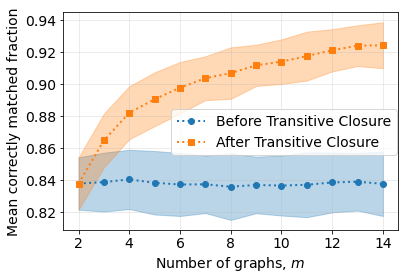

In [12]:
# Plot

ms = sorted(results.keys())
before_means = [results[m]['before_mean'] for m in ms]
before_stds = [results[m]['before_std'] for m in ms]
after_means = [results[m]['after_mean'] for m in ms]
after_stds = [results[m]['after_std'] for m in ms]

fs = 14 # font size
lw = 2 # line width

pre_upper = np.array(before_means) + np.array(before_stds)
pre_lower = np.array(before_means) - np.array(before_stds)

post_upper = np.array(after_means) + np.array(after_stds)
post_lower = np.array(after_means) - np.array(after_stds)


plt.plot(ms, before_means, ':o', linewidth = lw, label = 'Before Transitive Closure', color = 'C0')
plt.plot(ms, after_means, ':s', linewidth = lw, label = 'After Transitive Closure', color = 'C1')

plt.fill_between(ms, pre_lower, pre_upper, color='C0', alpha=0.3)
plt.fill_between(ms, post_lower, post_upper, color='C1', alpha=0.3)

plt.grid(alpha = 0.3)
plt.legend(loc='center', bbox_to_anchor=(0.66, 0.45), fontsize=fs)
plt.xlabel('Number of graphs, $m$', fontsize=fs)
plt.ylabel('Mean correctly matched fraction', fontsize=fs)

plt.xticks(np.arange(2,15,2), fontsize = fs)
plt.yticks(fontsize=fs)

plt.show()
#plt.savefig('fig-RGG.pdf', bbox_inches='tight', pad_inches=0)